<a href="https://colab.research.google.com/github/Eyram-G/trip/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✓ All libraries loaded

  STEP 1: LOADING FILES FROM GOOGLE DRIVE
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  Files in folder: ['Europe_Brent_Spot_Price_FOB (1).csv', 'Ghana_Fuel_Price_Dataset.xlsx', 'GHS_USD_ExchangeRate_2015_2025.xlsx', 'Ghana_Petrol_Prices_2010_2024.xlsx', 'Ghana_Fuel_Model_Results.xlsx']
  ✓ Petrol prices: 180 rows  (2010-01 to 2024-12)
  ✓ Brent crude:   180 rows  (2010-01 to 2024-12)
  ✓ Exchange rate: 120 rows
  ✓ Main dataset:  132 rows  cols: ['Brent_Crude_USD_per_Barrel', 'Inflation_Annual_PCT', 'GDP_USD', 'Population']

  ✓ Master dataset: 180 rows × 8 columns
  Columns: ['Petrol_GHS', 'GHS_per_USD', 'Petrol_USD', 'Brent_USD', 'Brent_Crude_USD_per_Barrel', 'Inflation_Annual_PCT', 'GDP_USD', 'Population']
  Missing values: 0

  Preview (first 3 rows):
            Petrol_GHS  GHS_per_USD  Petrol_USD  Brent_USD  Brent_Crude_USD_per_Barrel  Inflation_Annual_PCT       GDP_USD  

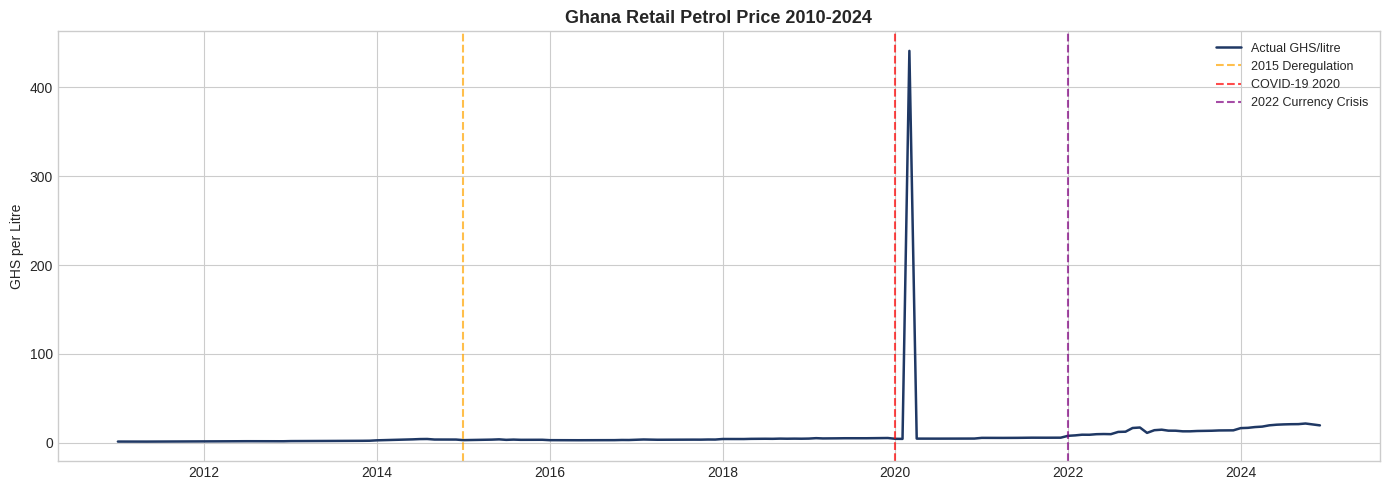

  ✓ Chart 1: Price history saved


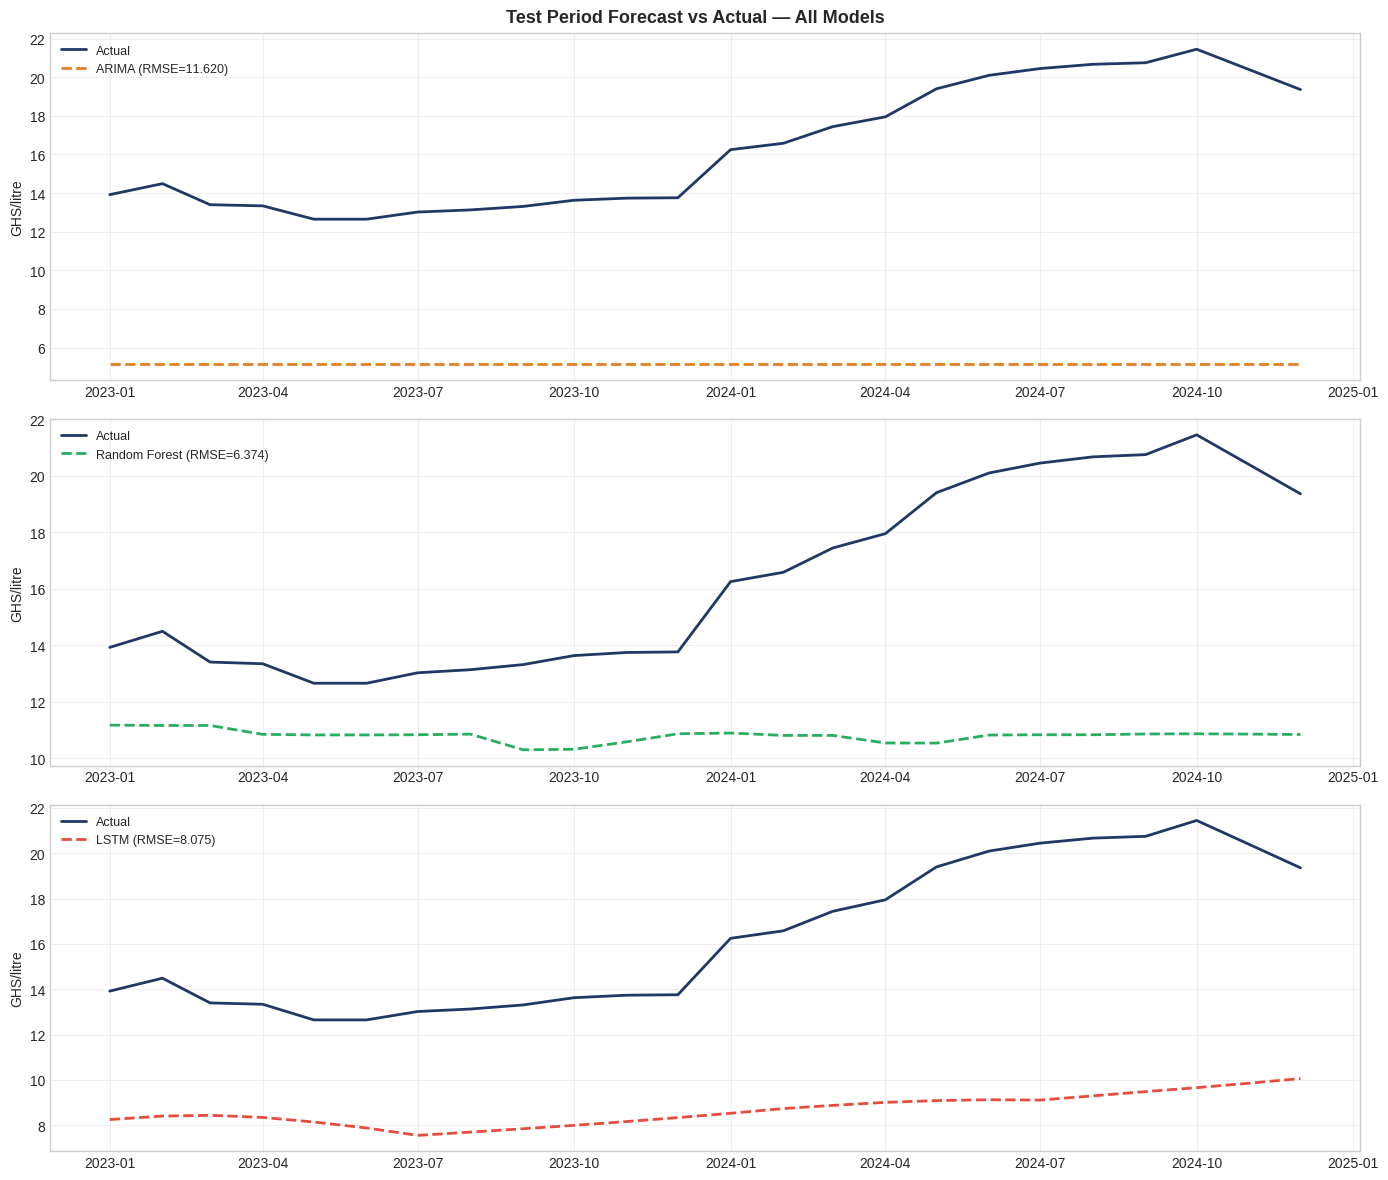

  ✓ Chart 2: Forecast vs Actual saved


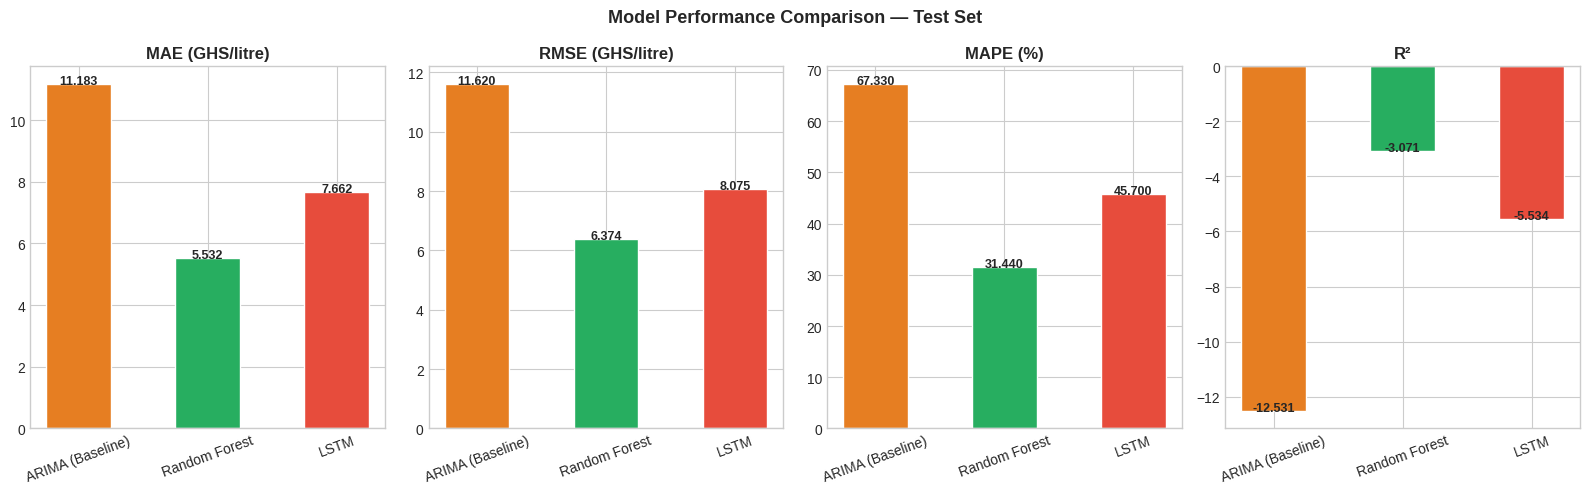

  ✓ Chart 3: Model comparison saved


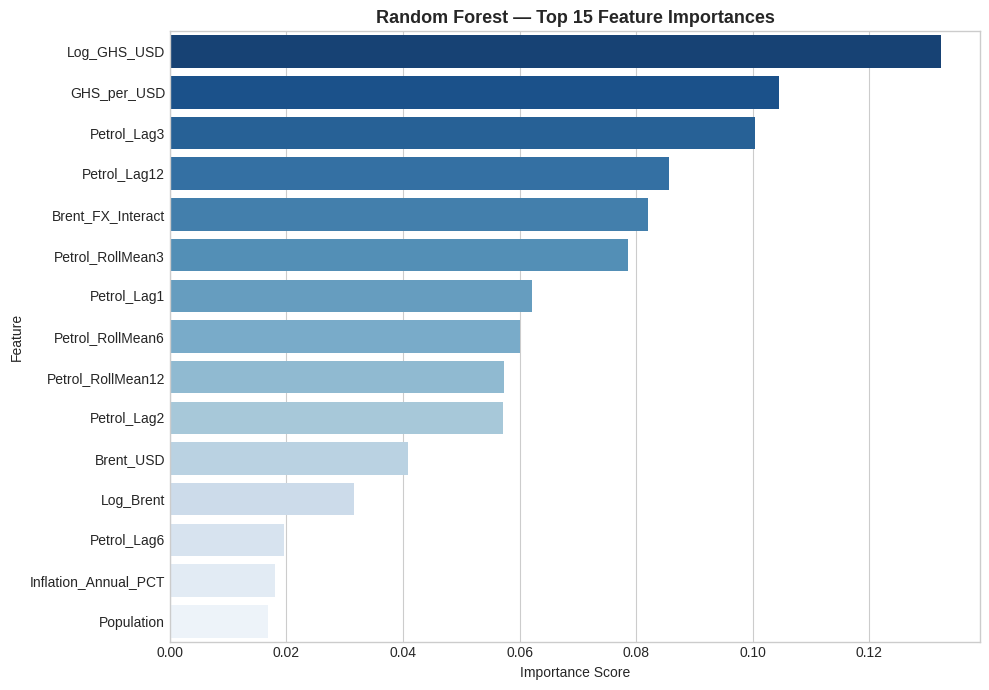

  ✓ Chart 4: Feature importance saved


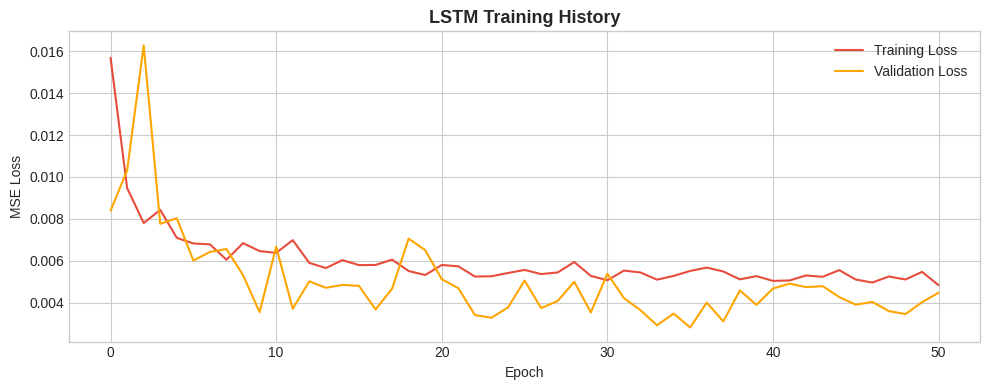

  ✓ Chart 5: LSTM training loss saved

  STEP 10: SAVING RESULTS TO EXCEL
  ✓ Saved to Google Drive: solo/Ghana_Fuel_Model_Results.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


  ALL DONE!
  Best model : Random Forest

  Downloaded:
    Ghana_Fuel_Model_Results.xlsx
      Sheet 1 — Results + DM Test
      Sheet 2 — Forecast Values
      Sheet 3 — Feature Importance
      Sheet 4 — All 5 Charts

    Chart1_Price_History.png
    Chart2_Forecast_vs_Actual.png
    Chart3_Model_Comparison.png
    Chart4_Feature_Importance.png
    Chart5_LSTM_Loss.png

  Paste the Step 8 results table to Claude
  and Chapter 4 will be written immediately.



In [5]:
# ================================================================
# GHANA FUEL PRICE PREDICTION — COMPLETE MODEL (FINAL VERSION)
# Ganyo Ernest Eyram | ID: 22424979
# MPhil Data Science | University of Ghana
# Supervisor: Dr Alvin Prince Ansah
# ================================================================
# HOW TO USE:
#   1. Open https://colab.research.google.com
#   2. Paste this ENTIRE script into ONE single cell
#   3. Press Shift + Enter
#   4. Sign in to Google Drive when prompted
#   5. Wait 5-10 minutes for full results
# ================================================================

# ── Install libraries ─────────────────────────────────────────
import subprocess
subprocess.run(["pip", "install", "pandas", "numpy", "matplotlib",
                "seaborn", "scikit-learn", "statsmodels",
                "tensorflow", "openpyxl", "scipy", "-q"])

# ── Imports ───────────────────────────────────────────────────
import os, warnings, shutil, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (mean_absolute_error,
                              mean_squared_error, r2_score)
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from scipy import stats
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from openpyxl import Workbook
from openpyxl.styles import (Font, PatternFill, Alignment,
                              Border, Side)
from openpyxl.utils import get_column_letter
from openpyxl.drawing.image import Image as XLImage
from google.colab import drive, files

warnings.filterwarnings("ignore")
tf.random.set_seed(42)
np.random.seed(42)
print("✓ All libraries loaded")


# ================================================================
# STEP 1 — MOUNT GOOGLE DRIVE AND LOAD FILES
# ================================================================
print("\n" + "="*55)
print("  STEP 1: LOADING FILES FROM GOOGLE DRIVE")
print("="*55)

drive.mount('/content/drive')
FOLDER = '/content/drive/MyDrive/solo/'
print(f"  Files in folder: {os.listdir(FOLDER)}")


# ── 1a. Petrol Prices ─────────────────────────────────────────
petrol_file = [f for f in os.listdir(FOLDER)
               if 'petrol' in f.lower() and f.endswith('.xlsx')][0]
df_p = pd.read_excel(FOLDER + petrol_file)
df_p = df_p.iloc[1:].copy()
df_p.columns = ['Date', 'Petrol_USD', 'GHS_per_USD', 'Petrol_GHS']
df_p['Date'] = pd.to_datetime(
    df_p['Date'].astype(str) + '-01', format='%Y-%m-%d')
df_p = df_p.set_index('Date')
for col in df_p.columns:
    df_p[col] = pd.to_numeric(df_p[col], errors='coerce')
print(f"  ✓ Petrol prices: {len(df_p)} rows  "
      f"({df_p.index[0].strftime('%Y-%m')} to "
      f"{df_p.index[-1].strftime('%Y-%m')})")


# ── 1b. Brent Crude (CSV with 4 header lines) ─────────────────
brent_file = [f for f in os.listdir(FOLDER)
              if 'brent' in f.lower() or 'europe' in f.lower()][0]
df_b = pd.read_csv(FOLDER + brent_file, skiprows=4)
df_b.columns = ['Date', 'Brent_USD']
df_b['Date'] = pd.to_datetime(
    df_b['Date'], format='%b %Y', errors='coerce')
df_b = df_b.dropna(subset=['Date'])
df_b['Brent_USD'] = pd.to_numeric(
    df_b['Brent_USD'], errors='coerce')
df_b = df_b.set_index('Date').sort_index()
df_b = df_b.resample('MS').mean().round(2)
df_b = df_b[(df_b.index.year >= 2010) &
             (df_b.index.year <= 2024)]
print(f"  ✓ Brent crude:   {len(df_b)} rows  "
      f"({df_b.index[0].strftime('%Y-%m')} to "
      f"{df_b.index[-1].strftime('%Y-%m')})")


# ── 1c. GHS/USD Exchange Rate ──────────────────────────────────
fx_file = [f for f in os.listdir(FOLDER)
           if 'ghs' in f.lower() or 'exchange' in f.lower()][0]
df_fx = pd.read_excel(FOLDER + fx_file)
if df_fx.iloc[0].astype(str).str.contains(
        'source|period|auto|yahoo', case=False).any():
    df_fx = df_fx.iloc[1:].copy()
df_fx = df_fx.iloc[:, :2].copy()
df_fx.columns = ['Date', 'GHS_per_USD_FX']
df_fx['Date'] = pd.to_datetime(
    df_fx['Date'].astype(str) + '-01',
    format='%Y-%m-%d', errors='coerce')
df_fx = df_fx.dropna(subset=['Date']).set_index('Date')
df_fx['GHS_per_USD_FX'] = pd.to_numeric(
    df_fx['GHS_per_USD_FX'], errors='coerce')
df_fx = df_fx[(df_fx.index.year >= 2010) &
               (df_fx.index.year <= 2024)]
print(f"  ✓ Exchange rate: {len(df_fx)} rows")


# ── 1d. Main Fuel Dataset (CPI, GDP, etc.) ────────────────────
try:
    main_file = [f for f in os.listdir(FOLDER)
                 if 'dataset' in f.lower() or
                 ('fuel' in f.lower() and
                  'petrol' not in f.lower())][0]
    df_m = pd.read_excel(FOLDER + main_file)
    if df_m.iloc[0].astype(str).str.contains(
            'source|period|auto', case=False).any():
        df_m = df_m.iloc[1:].copy()
    df_m.columns = [str(c) for c in df_m.columns]
    dc = df_m.columns[0]
    df_m[dc] = pd.to_datetime(
        df_m[dc].astype(str) + '-01',
        format='%Y-%m-%d', errors='coerce')
    df_m = df_m.dropna(subset=[dc]).set_index(dc)
    for col in df_m.columns:
        df_m[col] = pd.to_numeric(df_m[col], errors='coerce')
    # Drop columns that are entirely empty
    df_m = df_m.dropna(axis=1, how='all')
    print(f"  ✓ Main dataset:  {len(df_m)} rows  "
          f"cols: {list(df_m.columns)}")
except Exception as e:
    print(f"  ⚠ Main dataset skipped: {e}")
    df_m = pd.DataFrame()


# ── 1e. Build Master Monthly Dataset 2010-2024 ────────────────
dates  = pd.date_range('2010-01-01', '2024-12-31', freq='MS')
master = pd.DataFrame(index=dates)
master.index.name = 'Date'

master['Petrol_GHS']  = df_p['Petrol_GHS'].reindex(dates)
master['GHS_per_USD'] = df_p['GHS_per_USD'].reindex(dates)
master['Petrol_USD']  = df_p['Petrol_USD'].reindex(dates)
master['Brent_USD']   = df_b['Brent_USD'].reindex(dates)

# Fill exchange rate gaps with more detailed FX file
fx_fill = df_fx['GHS_per_USD_FX'].reindex(dates, method='ffill')
master['GHS_per_USD'] = master['GHS_per_USD'].fillna(fx_fill)

# Add non-empty columns from main dataset
if len(df_m) > 0:
    for col in df_m.columns:
        if col not in master.columns:
            master[col] = df_m[col].reindex(dates, method='ffill')

# Drop any columns that are still completely empty
master = master.dropna(axis=1, how='all')

# Forward/backward fill remaining gaps
master = master.ffill().bfill()

print(f"\n  ✓ Master dataset: {len(master)} rows × "
      f"{len(master.columns)} columns")
print(f"  Columns: {list(master.columns)}")
print(f"  Missing values: {master.isnull().sum().sum()}")
print(f"\n  Preview (first 3 rows):")
print(master.head(3).to_string())


# ================================================================
# STEP 2 — DATA PREPROCESSING
# ================================================================
print("\n" + "="*55)
print("  STEP 2: DATA PREPROCESSING")
print("="*55)

df = master.copy()

# 2.1 Stationarity test on target
print("  ADF Test on Petrol_GHS:")
adf = adfuller(df['Petrol_GHS'].dropna())
print(f"    ADF={adf[0]:.4f}  p={adf[1]:.4f}  "
      f"{'Stationary' if adf[1]<0.05 else 'Non-stationary'}")

# 2.2 Log transformations
df['Log_Petrol']  = np.log(df['Petrol_GHS'].clip(lower=0.01))
df['Log_GHS_USD'] = np.log(df['GHS_per_USD'].clip(lower=0.01))
df['Log_Brent']   = np.log(df['Brent_USD'].clip(lower=0.01))
print("  ✓ Log transforms applied")

# 2.3 Dummy variables
df['Policy_Dummy'] = (df.index.year >= 2015).astype(int)
df['COVID_Dummy']  = ((df.index.year == 2020) &
                       (df.index.month >= 3)).astype(int)
df['Crisis_2022']  = (df.index.year == 2022).astype(int)
print("  ✓ Dummy variables created")

# 2.4 Lag features
for lag in [1, 2, 3, 6, 12]:
    df[f'Petrol_Lag{lag}'] = df['Log_Petrol'].shift(lag)
    df[f'Brent_Lag{lag}']  = df['Log_Brent'].shift(lag)
print("  ✓ Lag features created (1,2,3,6,12 months)")

# 2.5 Rolling window statistics
for w in [3, 6, 12]:
    df[f'Petrol_RollMean{w}'] = (df['Log_Petrol'].shift(1)
                                   .rolling(w).mean())
    df[f'Petrol_RollStd{w}']  = (df['Log_Petrol'].shift(1)
                                   .rolling(w).std())
print("  ✓ Rolling statistics created (3,6,12 months)")

# 2.6 Interaction term and month
df['Brent_FX_Interact'] = df['Log_Brent'] * df['Log_GHS_USD']
df['Month'] = df.index.month
print("  ✓ Interaction term and month feature created")

# 2.7 Drop NaN only on lag/roll columns
lag_cols = [c for c in df.columns
            if 'Lag' in c or 'Roll' in c]
df = df.dropna(subset=lag_cols)
print(f"\n  ✓ Final dataset: {len(df)} rows")
print(f"    Range: {df.index[0].strftime('%Y-%m')} to "
      f"{df.index[-1].strftime('%Y-%m')}")
print(f"    Total features available: {len(df.columns)}")


# ================================================================
# STEP 3 — TRAIN / VALIDATION / TEST SPLIT
# ================================================================
print("\n" + "="*55)
print("  STEP 3: TRAIN / VALIDATION / TEST SPLIT")
print("="*55)

TARGET  = 'Log_Petrol'
EXCLUDE = ['Petrol_GHS', 'Log_Petrol', 'Petrol_USD']
FEATURES = [c for c in df.columns if c not in EXCLUDE]

X = df[FEATURES]
y = df[TARGET]

TRAIN_END = '2020-12-31'
VAL_END   = '2022-12-31'

X_train = X[X.index <= TRAIN_END]
y_train = y[y.index <= TRAIN_END]
X_val   = X[(X.index > TRAIN_END) & (X.index <= VAL_END)]
y_val   = y[(y.index > TRAIN_END) & (y.index <= VAL_END)]
X_test  = X[X.index > VAL_END]
y_test  = y[y.index > VAL_END]

print(f"  Training   : {len(X_train)} obs  "
      f"({X_train.index[0].strftime('%Y-%m')} to "
      f"{X_train.index[-1].strftime('%Y-%m')})")
print(f"  Validation : {len(X_val)} obs  "
      f"({X_val.index[0].strftime('%Y-%m')} to "
      f"{X_val.index[-1].strftime('%Y-%m')})")
print(f"  Test       : {len(X_test)} obs  "
      f"({X_test.index[0].strftime('%Y-%m')} to "
      f"{X_test.index[-1].strftime('%Y-%m')})")
print(f"  Features   : {len(FEATURES)}")


# ================================================================
# STEP 4 — ARIMA BASELINE
# ================================================================
print("\n" + "="*55)
print("  STEP 4: ARIMA BASELINE MODEL")
print("="*55)

y_ar_train = y[y.index <= TRAIN_END]
y_ar_test  = y[y.index > VAL_END]

best_aic   = np.inf
best_order = (1, 1, 1)
print("  Searching best ARIMA(p,d,q) by AIC...")
for p in range(0, 4):
    for d in [0, 1]:
        for q in range(0, 4):
            try:
                res = ARIMA(y_ar_train, order=(p,d,q)).fit()
                if res.aic < best_aic:
                    best_aic   = res.aic
                    best_order = (p, d, q)
            except:
                pass

print(f"  ✓ Best order: ARIMA{best_order}  AIC={best_aic:.2f}")

ar_result  = ARIMA(y_ar_train, order=best_order).fit()
ar_fc_log  = ar_result.forecast(steps=len(y_ar_test))
ar_fc_log  = pd.Series(ar_fc_log.values, index=y_ar_test.index)
ar_fc_ghs  = np.exp(ar_fc_log)
act_ar     = np.exp(y_ar_test)

ar_mae  = mean_absolute_error(act_ar, ar_fc_ghs)
ar_rmse = np.sqrt(mean_squared_error(act_ar, ar_fc_ghs))
ar_mape = np.mean(np.abs((act_ar-ar_fc_ghs)/act_ar))*100
ar_r2   = r2_score(act_ar, ar_fc_ghs)

print(f"\n  ARIMA Test Results:")
print(f"    MAE  = {ar_mae:.4f} GHS/litre")
print(f"    RMSE = {ar_rmse:.4f} GHS/litre")
print(f"    MAPE = {ar_mape:.2f}%")
print(f"    R²   = {ar_r2:.4f}")


# ================================================================
# STEP 5 — RANDOM FOREST
# ================================================================
print("\n" + "="*55)
print("  STEP 5: RANDOM FOREST MODEL")
print("="*55)

print("  Running grid search (2-3 minutes)...")
param_grid = {
    'n_estimators':      [100, 300, 500],
    'max_depth':         [5, 10, None],
    'max_features':      ['sqrt', 'log2'],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2],
}
tscv    = TimeSeriesSplit(n_splits=5)
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid, cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1, verbose=0
)
rf_grid.fit(pd.concat([X_train, X_val]),
            pd.concat([y_train, y_val]))
best_params = rf_grid.best_params_
print(f"  ✓ Best params: {best_params}")

rf_model   = RandomForestRegressor(
    **best_params, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_fc_log  = rf_model.predict(X_test)
rf_fc_ghs  = np.exp(rf_fc_log)
act_rf     = np.exp(y_test.values)

rf_mae  = mean_absolute_error(act_rf, rf_fc_ghs)
rf_rmse = np.sqrt(mean_squared_error(act_rf, rf_fc_ghs))
rf_mape = np.mean(np.abs((act_rf-rf_fc_ghs)/act_rf))*100
rf_r2   = r2_score(act_rf, rf_fc_ghs)

print(f"\n  Random Forest Test Results:")
print(f"    MAE  = {rf_mae:.4f} GHS/litre")
print(f"    RMSE = {rf_rmse:.4f} GHS/litre")
print(f"    MAPE = {rf_mape:.2f}%")
print(f"    R²   = {rf_r2:.4f}")

feat_imp = pd.DataFrame({
    'Feature':    FEATURES,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)
print(f"\n  Top 5 Features:")
print(feat_imp.head(5).to_string(index=False))


# ================================================================
# STEP 6 — LSTM
# ================================================================
print("\n" + "="*55)
print("  STEP 6: LSTM NEURAL NETWORK")
print("="*55)

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_tr_s = scaler_X.fit_transform(X_train)
X_vl_s = scaler_X.transform(X_val)
X_te_s = scaler_X.transform(X_test)
y_tr_s = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_vl_s = scaler_y.transform(y_val.values.reshape(-1,1))
y_te_s = scaler_y.transform(y_test.values.reshape(-1,1))

LOOKBACK = 6

def make_seqs(X, y, lb):
    Xs, ys = [], []
    for i in range(lb, len(X)):
        Xs.append(X[i-lb:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_tr_seq, y_tr_seq = make_seqs(X_tr_s, y_tr_s, LOOKBACK)
X_vl_seq, y_vl_seq = make_seqs(
    np.vstack([X_tr_s[-LOOKBACK:], X_vl_s]),
    np.vstack([y_tr_s[-LOOKBACK:], y_vl_s]),
    LOOKBACK)
X_te_seq, y_te_seq = make_seqs(
    np.vstack([X_vl_s[-LOOKBACK:], X_te_s]),
    np.vstack([y_vl_s[-LOOKBACK:], y_te_s]),
    LOOKBACK)

print(f"  Sequences — Train:{X_tr_seq.shape}  "
      f"Val:{X_vl_seq.shape}  Test:{X_te_seq.shape}")

n_feat = X_tr_s.shape[1]
lstm_model = Sequential([
    LSTM(64, return_sequences=True,
         input_shape=(LOOKBACK, n_feat)),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')

es = EarlyStopping(monitor='val_loss', patience=15,
                   restore_best_weights=True, verbose=0)
print("  Training LSTM...")
history = lstm_model.fit(
    X_tr_seq, y_tr_seq,
    validation_data=(X_vl_seq, y_vl_seq),
    epochs=200, batch_size=16,
    callbacks=[es], verbose=0)
print(f"  ✓ Trained for {len(history.history['loss'])} epochs")

lstm_pred_s  = lstm_model.predict(X_te_seq, verbose=0)
lstm_fc_log  = scaler_y.inverse_transform(
    lstm_pred_s).flatten()
lstm_fc_ghs  = np.exp(lstm_fc_log)
act_lstm     = np.exp(
    scaler_y.inverse_transform(y_te_seq).flatten())

lstm_mae  = mean_absolute_error(act_lstm, lstm_fc_ghs)
lstm_rmse = np.sqrt(mean_squared_error(act_lstm, lstm_fc_ghs))
lstm_mape = np.mean(np.abs(
    (act_lstm-lstm_fc_ghs)/act_lstm))*100
lstm_r2   = r2_score(act_lstm, lstm_fc_ghs)

print(f"\n  LSTM Test Results:")
print(f"    MAE  = {lstm_mae:.4f} GHS/litre")
print(f"    RMSE = {lstm_rmse:.4f} GHS/litre")
print(f"    MAPE = {lstm_mape:.2f}%")
print(f"    R²   = {lstm_r2:.4f}")


# ================================================================
# STEP 7 — DIEBOLD-MARIANO TEST
# ================================================================
print("\n" + "="*55)
print("  STEP 7: DIEBOLD-MARIANO TEST")
print("="*55)

def dm_test(actual, f1, f2):
    d     = (actual-f1)**2 - (actual-f2)**2
    d_bar = np.mean(d)
    var_d = np.var(d, ddof=1) / len(d)
    DM    = d_bar / np.sqrt(var_d)
    p_val = 2*(1-stats.norm.cdf(np.abs(DM)))
    return round(float(DM),4), round(float(p_val),4)

n  = min(len(act_ar), len(act_rf), len(act_lstm))
a  = np.exp(y_test.values[-n:])
ar = ar_fc_ghs.values[-n:]
rf = rf_fc_ghs[-n:]
ls = lstm_fc_ghs[-n:]

dm1,p1 = dm_test(a, ar, rf)
dm2,p2 = dm_test(a, ar, ls)
dm3,p3 = dm_test(a, rf, ls)

print(f"  RF vs ARIMA   : DM={dm1:>8}  p={p1}  "
      f"{'✓ Significant' if p1<0.05 else 'Not significant'}")
print(f"  LSTM vs ARIMA : DM={dm2:>8}  p={p2}  "
      f"{'✓ Significant' if p2<0.05 else 'Not significant'}")
print(f"  RF vs LSTM    : DM={dm3:>8}  p={p3}  "
      f"{'✓ Significant' if p3<0.05 else 'Not significant'}")


# ================================================================
# STEP 8 — FINAL RESULTS TABLE
# ================================================================
print("\n" + "="*55)
print("  STEP 8: FINAL RESULTS TABLE")
print("="*55)

results = pd.DataFrame({
    'Model':            ['ARIMA (Baseline)',
                         'Random Forest', 'LSTM'],
    'MAE (GHS/litre)':  [round(ar_mae,4),
                          round(rf_mae,4),  round(lstm_mae,4)],
    'RMSE (GHS/litre)': [round(ar_rmse,4),
                          round(rf_rmse,4), round(lstm_rmse,4)],
    'MAPE (%)':         [round(ar_mape,2),
                          round(rf_mape,2),  round(lstm_mape,2)],
    'R²':               [round(ar_r2,4),
                          round(rf_r2,4),    round(lstm_r2,4)],
})
print(results.to_string(index=False))
best = results.loc[
    results['RMSE (GHS/litre)'].idxmin(), 'Model']
print(f"\n  ✓ Best performing model: {best}")


# ================================================================
# STEP 9 — CHARTS
# ================================================================
print("\n" + "="*55)
print("  STEP 9: GENERATING CHARTS")
print("="*55)

plt.style.use('seaborn-v0_8-whitegrid')
C = {'actual':'#1F3864','arima':'#E67E22',
     'rf':'#27AE60','lstm':'#E74C3C'}

# Chart 1: Full price history
fig1, ax1 = plt.subplots(figsize=(14,5))
ax1.plot(df.index, df['Petrol_GHS'],
         color=C['actual'], linewidth=1.8,
         label='Actual GHS/litre')
for yr, lbl, col in [
    (2015,'2015 Deregulation','orange'),
    (2020,'COVID-19 2020','red'),
    (2022,'2022 Currency Crisis','purple')]:
    ax1.axvline(pd.Timestamp(f'{yr}-01-01'),
                color=col, linestyle='--',
                alpha=0.7, label=lbl)
ax1.set_title(
    'Ghana Retail Petrol Price 2010-2024',
    fontsize=13, fontweight='bold')
ax1.set_ylabel('GHS per Litre')
ax1.legend(fontsize=9)
plt.tight_layout()
plt.savefig('Chart1_Price_History.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("  ✓ Chart 1: Price history saved")

# Chart 2: All 3 forecasts vs actual
fig2, axes = plt.subplots(3, 1, figsize=(14,12))
fig2.suptitle(
    'Test Period Forecast vs Actual — All Models',
    fontsize=13, fontweight='bold')
test_idx = X_test.index[-n:]
for ax, fc, act_vals, col, lbl in [
    (axes[0], ar, a,  C['arima'],
     f'ARIMA (RMSE={ar_rmse:.3f})'),
    (axes[1], rf, a,  C['rf'],
     f'Random Forest (RMSE={rf_rmse:.3f})'),
    (axes[2], ls, a,  C['lstm'],
     f'LSTM (RMSE={lstm_rmse:.3f})'),
]:
    ax.plot(test_idx, act_vals,
            color=C['actual'], linewidth=2,
            label='Actual')
    ax.plot(test_idx, fc, color=col,
            linewidth=2, linestyle='--',
            label=lbl)
    ax.set_ylabel('GHS/litre')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Chart2_Forecast_vs_Actual.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("  ✓ Chart 2: Forecast vs Actual saved")

# Chart 3: Model comparison bars
fig3, axes3 = plt.subplots(1, 4, figsize=(16,5))
fig3.suptitle(
    'Model Performance Comparison — Test Set',
    fontsize=13, fontweight='bold')
bar_cols = [C['arima'], C['rf'], C['lstm']]
for idx, metric in enumerate([
        'MAE (GHS/litre)', 'RMSE (GHS/litre)',
        'MAPE (%)', 'R²']):
    bars = axes3[idx].bar(
        results['Model'], results[metric],
        color=bar_cols, edgecolor='white', width=0.5)
    axes3[idx].set_title(metric, fontweight='bold')
    for bar, val in zip(bars, results[metric]):
        axes3[idx].text(
            bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.001,
            f'{val:.3f}', ha='center',
            fontsize=9, fontweight='bold')
    axes3[idx].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('Chart3_Model_Comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("  ✓ Chart 3: Model comparison saved")

# Chart 4: Feature importance
fig4, ax4 = plt.subplots(figsize=(10,7))
sns.barplot(data=feat_imp, x='Importance',
            y='Feature', palette='Blues_r', ax=ax4)
ax4.set_title(
    'Random Forest — Top 15 Feature Importances',
    fontsize=13, fontweight='bold')
ax4.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('Chart4_Feature_Importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("  ✓ Chart 4: Feature importance saved")

# Chart 5: LSTM training loss
fig5, ax5 = plt.subplots(figsize=(10,4))
ax5.plot(history.history['loss'],
         label='Training Loss', color=C['lstm'])
ax5.plot(history.history['val_loss'],
         label='Validation Loss', color='orange')
ax5.set_title('LSTM Training History',
              fontsize=13, fontweight='bold')
ax5.set_xlabel('Epoch')
ax5.set_ylabel('MSE Loss')
ax5.legend()
plt.tight_layout()
plt.savefig('Chart5_LSTM_Loss.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("  ✓ Chart 5: LSTM training loss saved")


# ================================================================
# STEP 10 — SAVE TO EXCEL
# ================================================================
print("\n" + "="*55)
print("  STEP 10: SAVING RESULTS TO EXCEL")
print("="*55)

wb   = Workbook()
hdr  = Font(name='Times New Roman', bold=True,
             color='FFFFFF', size=11)
blu  = PatternFill('solid', start_color='1F3864')
grn  = PatternFill('solid', start_color='1E8449')
dat  = Font(name='Times New Roman', size=10)
bld  = Font(name='Times New Roman', size=10, bold=True)
ctr  = Alignment(horizontal='center',
                  vertical='center', wrap_text=True)
thin = Side(style='thin', color='CCCCCC')
bdr  = Border(left=thin, right=thin,
               top=thin,  bottom=thin)

def write_hdr(ws, headers, row=1):
    for c, h in enumerate(headers, 1):
        cell = ws.cell(row=row, column=c, value=h)
        cell.font=hdr; cell.fill=blu
        cell.alignment=ctr; cell.border=bdr

def write_row(ws, row_idx, values,
              highlight=False):
    fill = grn if highlight else PatternFill()
    for c, val in enumerate(values, 1):
        cell = ws.cell(row=row_idx, column=c,
                       value=val)
        cell.font = dat
        cell.alignment = ctr
        cell.border = bdr
        if highlight:
            cell.fill = fill

# Sheet 1: Model Results
ws1 = wb.active
ws1.title = 'Model Results'
write_hdr(ws1, ['Model','MAE (GHS/litre)',
                'RMSE (GHS/litre)','MAPE (%)','R²'])
for i, row in results.iterrows():
    write_row(ws1, i+2, list(row),
              highlight=(row['Model']==best))
for i in range(1,6):
    ws1.column_dimensions[
        get_column_letter(i)].width = 22
ws1.row_dimensions[1].height = 35

# DM Test
ws1.cell(row=7, column=1,
         value='Diebold-Mariano Test').font = bld
write_hdr(ws1, ['Comparison','DM Stat',
                'p-value','Significant?'], row=8)
for i, row_d in enumerate([
    ['RF vs ARIMA',   dm1, p1,
     'Yes' if p1<0.05 else 'No'],
    ['LSTM vs ARIMA', dm2, p2,
     'Yes' if p2<0.05 else 'No'],
    ['RF vs LSTM',    dm3, p3,
     'Yes' if p3<0.05 else 'No'],
], 9):
    write_row(ws1, i, row_d)

# Sheet 2: Forecast Values
ws2 = wb.create_sheet('Forecast Values')
write_hdr(ws2, ['Date','Actual (GHS/litre)',
                'ARIMA','Random Forest','LSTM'])
for i in range(n):
    write_row(ws2, i+2, [
        test_idx[i].strftime('%Y-%m'),
        round(float(a[i]),4),
        round(float(ar[i]),4),
        round(float(rf[i]),4),
        round(float(ls[i]),4),
    ])
for i in range(1,6):
    ws2.column_dimensions[
        get_column_letter(i)].width = 22
ws2.row_dimensions[1].height = 35

# Sheet 3: Feature Importance
ws3 = wb.create_sheet('Feature Importance')
write_hdr(ws3, ['Rank','Feature',
                'Importance Score'])
for i, row in feat_imp.reset_index(
        drop=True).iterrows():
    write_row(ws3, i+2, [
        i+1, row['Feature'],
        round(row['Importance'],6)])
ws3.column_dimensions['A'].width = 8
ws3.column_dimensions['B'].width = 38
ws3.column_dimensions['C'].width = 22
ws3.row_dimensions[1].height = 35

# Sheet 4: Charts
ws4 = wb.create_sheet('Charts')
for img_file, anchor, w, h in [
    ('Chart1_Price_History.png',      'A1',   820, 320),
    ('Chart2_Forecast_vs_Actual.png', 'A22',  820, 700),
    ('Chart3_Model_Comparison.png',   'A65',  820, 320),
    ('Chart4_Feature_Importance.png', 'A86',  620, 430),
    ('Chart5_LSTM_Loss.png',          'A110', 620, 260),
]:
    try:
        img = XLImage(img_file)
        img.width=w; img.height=h
        ws4.add_image(img, anchor)
    except Exception as e:
        ws4[anchor] = f"Chart not embedded: {e}"

# Save
out = 'Ghana_Fuel_Model_Results.xlsx'
wb.save(out)

# Copy to Google Drive
try:
    shutil.copy(out, FOLDER + out)
    print(f"  ✓ Saved to Google Drive: solo/{out}")
except Exception as e:
    print(f"  ⚠ Drive copy: {e}")

# Download all files
files.download(out)
for chart in [
    'Chart1_Price_History.png',
    'Chart2_Forecast_vs_Actual.png',
    'Chart3_Model_Comparison.png',
    'Chart4_Feature_Importance.png',
    'Chart5_LSTM_Loss.png']:
    files.download(chart)

print(f"""
================================================
  ALL DONE!
================================================
  Best model : {best}

  Downloaded:
    Ghana_Fuel_Model_Results.xlsx
      Sheet 1 — Results + DM Test
      Sheet 2 — Forecast Values
      Sheet 3 — Feature Importance
      Sheet 4 — All 5 Charts

    Chart1_Price_History.png
    Chart2_Forecast_vs_Actual.png
    Chart3_Model_Comparison.png
    Chart4_Feature_Importance.png
    Chart5_LSTM_Loss.png

  Paste the Step 8 results table to Claude
  and Chapter 4 will be written immediately.
================================================
""")